# 6 DOF Ballistics Simulation Visualization
Visualizes trajectory and orientation from the C++ simulation output.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# %matplotlib widget

# Load simulation data
df = pd.read_csv('trajectory.csv')

t  = df['t'].values
x  = df['x'].values
y  = df['y'].values
z  = df['z'].values
qw = df['qw'].values
qx = df['qx'].values
qy = df['qy'].values
qz = df['qz'].values
tx = df['tx'].values
ty = df['ty'].values
tz = df['tz'].values
Vc = df['Vc'].values
rng= df['range'].values
nCx = df['nCx'].values
nCy = df['nCy'].values
nCz = df['nCz'].values


print(f'Loaded {len(df)} timesteps')
print(f'Time range: {t[0]:.2f}s to {t[-1]:.2f}s')
# print(f'Max height: {z.max():.2f}ft at t={t[z.argmax()]:.2f}s')
print(f'Min range: {rng.min():.2f}ft at t={t[rng.argmin()]:2f}s')

Loaded 2328 timesteps
Time range: 0.00s to 2.14s
Min range: 10.94ft at t=2.136800s


## 2. 3D Trajectory with Orientation Arrows

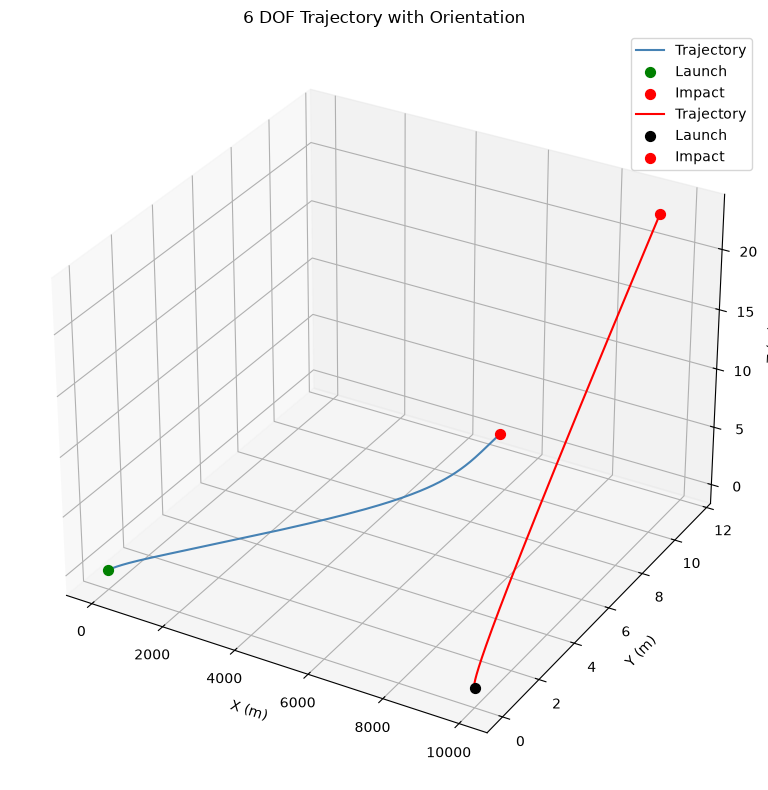

In [34]:
def quat_to_rotation_matrix(w, x, y, z):
    """Convert quaternion to 3x3 rotation matrix."""
    return np.array([
        [1-2*(y**2+z**2), 2*(x*y-z*w),     2*(x*z+y*w)    ],
        [2*(x*y+z*w),     1-2*(x**2+z**2), 2*(y*z-x*w)    ],
        [2*(x*z-y*w),     2*(y*z+x*w),     1-2*(x**2+y**2)]
    ])

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')

# Plot trajectory
ax.plot(x, y, z, color='steelblue', linewidth=1.5, label='Trajectory')
ax.scatter(x[0],  y[0],  z[0],  color='green', s=50, zorder=5, label='Launch')
ax.scatter(x[-1], y[-1], z[-1], color='red',   s=50, zorder=5, label='Impact')


ax.plot(tx, ty, tz, color='red', linewidth=1.5, label='Trajectory')
ax.scatter(tx[0],  ty[0],  tz[0],  color='black', s=50, zorder=5, label='Launch')
ax.scatter(tx[-1], ty[-1], tz[-1], color='red',   s=50, zorder=5, label='Impact')


# # Draw orientation arrows at regular intervals
# arrow_interval = max(1, len(df) // 20)  # ~20 arrows total
# arrow_scale    = max(z.max(), x.max()) * 0.05  # scale relative to trajectory size
# nose_vector    = np.array([0.0, 0.0, 1.0])  # projectile nose points along z in body frame

# for i in range(0, len(df), arrow_interval):
#     R   = quat_to_rotation_matrix(qw[i], qx[i], qy[i], qz[i])
#     dir = R @ nose_vector * arrow_scale
#     ax.quiver(
#         x[i], y[i], z[i],
#         dir[0], dir[1], dir[2],
#         color='darkorange', linewidth=1.2, arrow_length_ratio=0.3
#     )

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('6 DOF Trajectory with Orientation')
ax.legend()
plt.tight_layout()
plt.show()

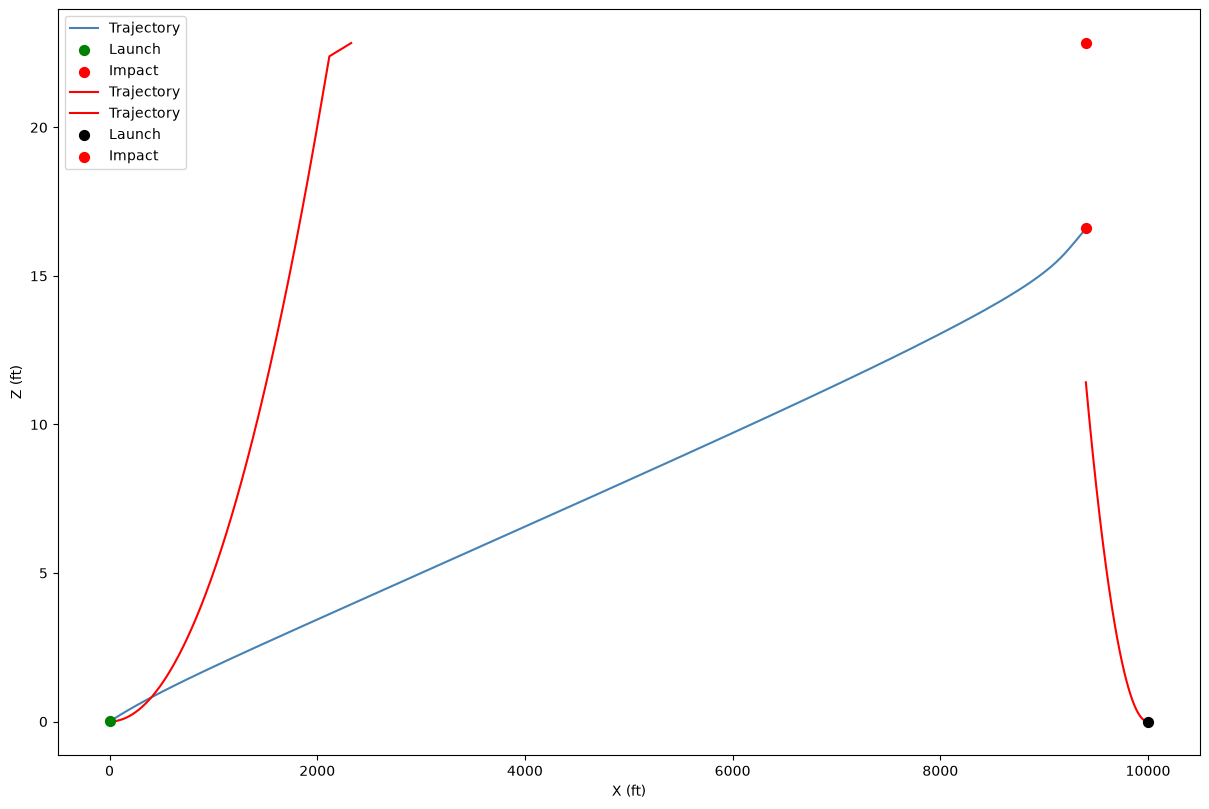

In [35]:
fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111)

# Plot trajectory
ax.plot(x, z, color='steelblue', linewidth=1.5, label='Trajectory')
ax.scatter(x[0],  z[0],  color='green', s=50, zorder=5, label='Launch')
ax.scatter(x[-1], z[-1], color='red',   s=50, zorder=5, label='Impact')

ax.plot(tx, ty, tz, color='red', linewidth=1.5, label='Trajectory')
ax.scatter(tx[0],  tz[0],  color='black', s=50, zorder=5, label='Launch')
ax.scatter(tx[-1], tz[-1], color='red',   s=50, zorder=5, label='Impact')

# ax.set_xlim((0,1200))
# ax.set_ylim((-200,100))
ax.legend()
plt.tight_layout()
ax.set_xlabel('X (ft)')
ax.set_ylabel('Z (ft)')
plt.show()

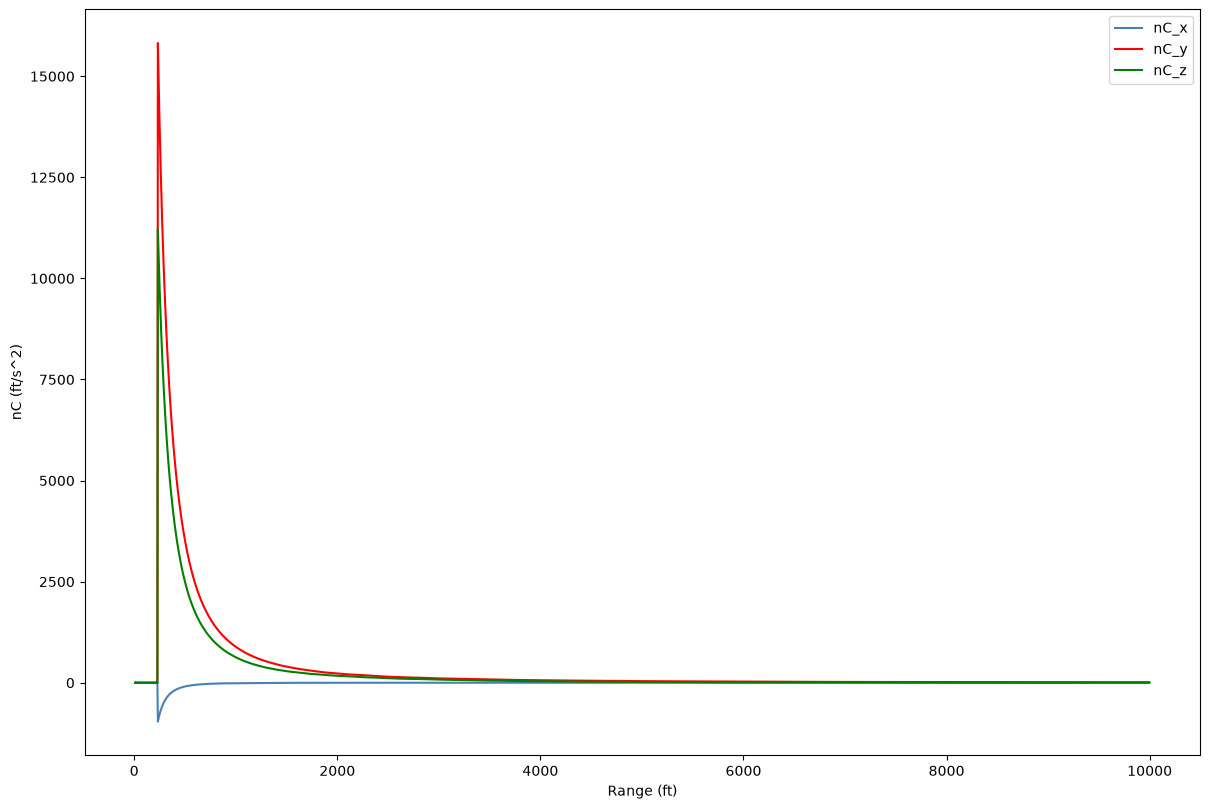

In [36]:
fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111)

# Plot trajectory
ax.plot(rng, nCx, color='steelblue', linewidth=1.5, label='nC_x')
ax.plot(rng, nCy, color='red', linewidth=1.5, label='nC_y')
ax.plot(rng, nCz, color='green', linewidth=1.5, label='nC_z')

# ax.set_xlim((0,200))
# ax.set_ylim((950,1020))
ax.legend()
plt.tight_layout()
ax.set_xlabel('Range (ft)')
ax.set_ylabel('nC (ft/s^2)')
plt.show()

C:\Users\derek\AppData\Local\Temp\ipykernel_21996\1358023442.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


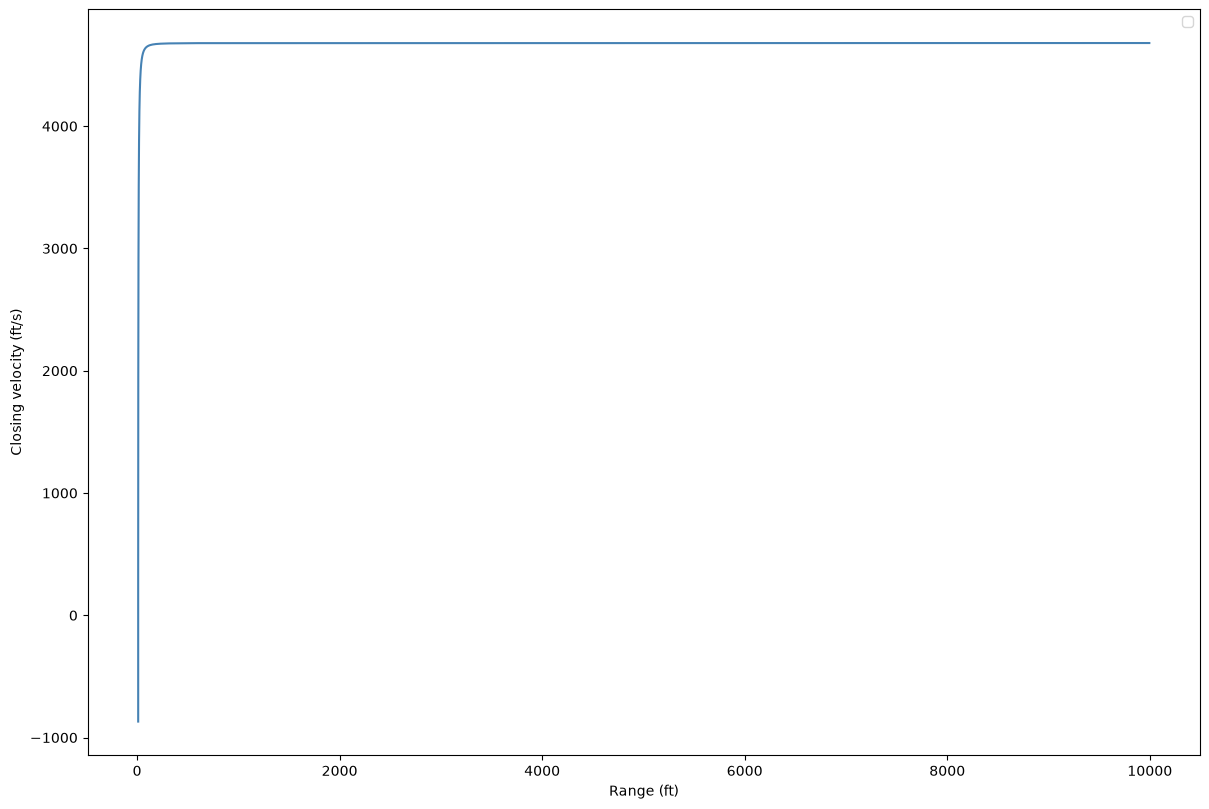

In [37]:
fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111)

# Plot trajectory
ax.plot(rng, Vc, color='steelblue', linewidth=1.5)

# ax.set_xlim((0,2000))
# ax.set_ylim((950,1020))
ax.legend()
plt.tight_layout()
ax.set_xlabel('Range (ft)')
ax.set_ylabel('Closing velocity (ft/s)')
plt.show()

## 1. Quaternion Components and Normalization

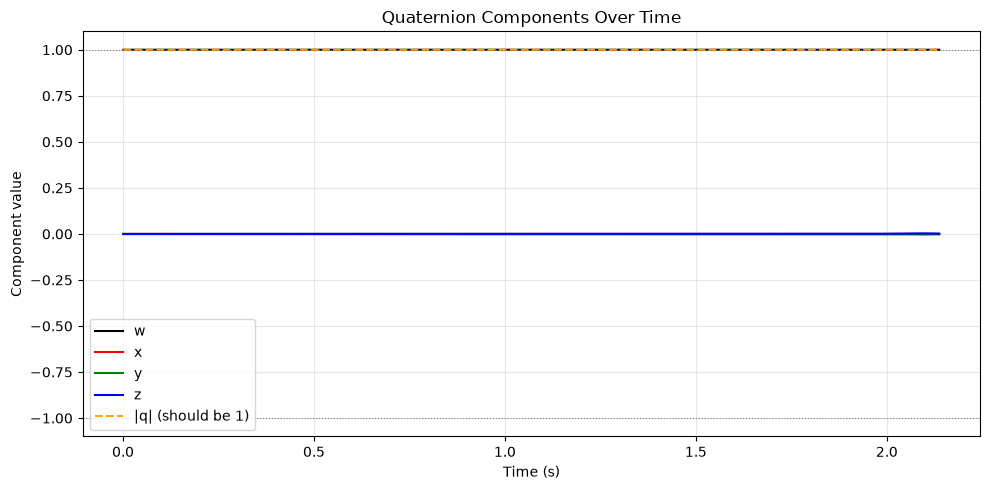

In [38]:
magnitude = np.sqrt(qw**2 + qx**2 + qy**2 + qz**2)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, qw, label='w', color='black')
ax.plot(t, qx, label='x', color='red')
ax.plot(t, qy, label='y', color='green')
ax.plot(t, qz, label='z', color='blue')
ax.plot(t, magnitude, label='|q| (should be 1)', color='orange', linestyle='--')
ax.axhline(y=1.0,  color='gray', linestyle=':', linewidth=0.8)
ax.axhline(y=-1.0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Component value')
ax.set_title('Quaternion Components Over Time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
## 3. Euler Angles Over Time

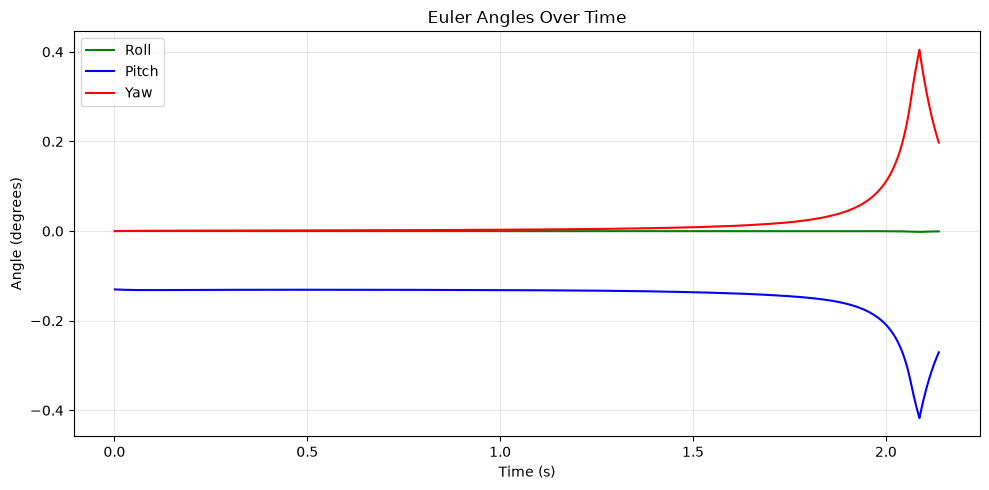

In [40]:
# Convert quaternion to Euler angles (roll, pitch, yaw)
roll  = np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))
pitch = np.arcsin(np.clip(2*(qw*qy - qz*qx), -1.0, 1.0))
yaw   = np.arctan2(2*(qw*qz + qx*qy), 1 - 2*(qy**2 + qz**2))

# Convert to degrees and unwrap to remove discontinuities
roll_deg  = np.degrees(np.unwrap(roll))
pitch_deg = np.degrees(np.unwrap(pitch))
yaw_deg   = np.degrees(np.unwrap(yaw))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, roll_deg,  label='Roll',  color='green')
ax.plot(t, pitch_deg, label='Pitch', color='blue')
ax.plot(t, yaw_deg,   label='Yaw',   color='red')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angle (degrees)')
ax.set_title('Euler Angles Over Time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()